# 2.3 Complex Machine Learning Models and Keras Part 2 - 3. Maastricht Results (ALL years)

## 01 Load Libraries & Dataset
## 02 Clean & Wrangle
## 03 Shaping Data
## 04 Spliting Data
## 05 Training a Random Forest Classifier
## 06 Feature Importance Analysis
## 07 Insights

### 01 Load Libraries & Dataset

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn.model_selection import train_test_split
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.metrics import accuracy_score

In [25]:
# Create a path for the import of dataset

path = r'C:\Users\wallm\02 2025 Machine Learning Project\02 Data'

In [26]:
# Import weather dataset

climate = pd.read_csv(os.path.join(path, '02 Prepared Data', 'Dataset-weather-cleaned-reshaped.csv'))

In [27]:
climate.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max,KASSEL_cloud_cover,STOCKHOLM_humidity,MUNCHENB_pressure
0,19600101,-1.6,0.661,0.826,-0.002,-1.101,-0.265,-0.903,-0.529,-0.846,...,-1.300,-0.806,-0.088,0.372,-0.668,-0.520,-0.752,0.714,1.544,0.095
1,19600102,-1.6,0.245,0.736,-0.002,-1.058,1.659,-0.810,-0.583,-0.462,...,-1.262,-1.042,0.503,-0.829,-0.548,-0.629,-0.407,1.176,-0.712,0.067
2,19600103,-1.6,1.076,1.278,-0.002,-1.251,0.156,-1.065,-0.257,-0.187,...,-0.433,-1.136,-0.396,-1.010,-0.067,0.054,-0.177,0.252,-0.274,0.132
3,19600104,-1.6,-1.002,1.458,-0.002,-0.822,-0.446,-0.114,-0.556,-0.386,...,0.388,-1.183,0.669,-1.040,-0.999,-0.164,-0.839,1.176,1.544,0.419
4,19600105,-1.6,0.245,1.729,-0.002,-0.747,-0.165,0.187,-1.004,-1.076,...,1.730,-0.795,-0.491,0.673,-1.509,-1.340,-1.471,0.252,1.419,0.388


In [28]:
climate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22950 entries, 0 to 22949
Columns: 137 entries, DATE to MUNCHENB_pressure
dtypes: float64(136), int64(1)
memory usage: 24.0 MB


In [29]:
climate.shape

(22950, 137)

In [30]:
# Import the 'Pleasant weather' dataset

pleasantweather = pd.read_csv(os.path.join(path, '01 Original Data', 'Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv'))

In [31]:
pleasantweather.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [32]:
pleasantweather.shape

(22950, 16)

### 02 Clean & Wrangle

In [34]:
climate.isnull().sum()

DATE                  0
MONTH                 0
BASEL_cloud_cover     0
BASEL_humidity        0
BASEL_pressure        0
                     ..
VALENTIA_temp_min     0
VALENTIA_temp_max     0
KASSEL_cloud_cover    0
STOCKHOLM_humidity    0
MUNCHENB_pressure     0
Length: 137, dtype: int64

In [35]:
pleasantweather.isnull().sum()

DATE                           0
BASEL_pleasant_weather         0
BELGRADE_pleasant_weather      0
BUDAPEST_pleasant_weather      0
DEBILT_pleasant_weather        0
DUSSELDORF_pleasant_weather    0
HEATHROW_pleasant_weather      0
KASSEL_pleasant_weather        0
LJUBLJANA_pleasant_weather     0
MAASTRICHT_pleasant_weather    0
MADRID_pleasant_weather        0
MUNCHENB_pleasant_weather      0
OSLO_pleasant_weather          0
SONNBLICK_pleasant_weather     0
STOCKHOLM_pleasant_weather     0
VALENTIA_pleasant_weather      0
dtype: int64

In [36]:
# Filter for columns related to 'München' station
Maastricht_station = [x for x in climate.columns if 'MAASTRICHT' in x.upper()]

# Create a new DataFrame for Maastricht station data
Maastricht_df = climate[Maastricht_station]

Maastricht_df

,MAASTRICHT_cloud_cover,MAASTRICHT_humidity,MAASTRICHT_pressure,MAASTRICHT_global_radiation,MAASTRICHT_precipitation,MAASTRICHT_sunshine,MAASTRICHT_temp_mean,MAASTRICHT_temp_min,MAASTRICHT_temp_max
0,0.704,0.268,-1.044,-1.052,0.252,-0.811,-0.097,0.383,-0.388
1,1.146,1.072,-1.055,-1.108,2.569,-0.959,-0.232,0.216,-0.543
2,0.704,1.519,0.074,-1.163,0.571,-1.058,-0.487,-0.118,-0.543
3,0.704,0.804,1.257,-1.119,-0.474,-0.984,-0.472,-0.535,-0.530
4,0.704,1.072,1.063,-1.163,0.798,-1.058,-0.307,-0.618,-0.388
...,...,...,...,...,...,...,...,...,...
22945,1.146,-1.162,0.440,-0.001,-0.020,0.251,1.268,1.317,1.094
22946,0.704,-0.894,0.322,-0.001,-0.020,0.177,1.313,1.601,1.210
22947,1.146,-0.984,0.246,-0.001,-0.020,-0.268,1.208,1.251,1.313
22948,1.146,-0.626,0.225,-0.001,-0.020,0.621,0.923,1.100,0.939


In [37]:
# Reduce pleasantweather dataset to Maastricht's data only

pleasantweather_Maastricht = pleasantweather['MAASTRICHT_pleasant_weather']

pleasantweather_Maastricht

0        0
1        0
2        0
3        0
4        0
        ..
22945    0
22946    0
22947    0
22948    0
22949    0
Name: MAASTRICHT_pleasant_weather, Length: 22950, dtype: int64

In [38]:
#Check the shape

Maastricht_df.shape 

(22950, 9)

In [39]:
#Check the shape

pleasantweather_Maastricht.shape

(22950,)

### 03 Shaping Data

In [41]:
# Define features and target for Maastricht

X_Maastricht = Maastricht_df  # Maastricht weather features
y_Maastricht = pleasantweather['MAASTRICHT_pleasant_weather']  # Maastricht target labels

# Convert to NumPy arrays

X = np.array(X_Maastricht)
y = np.array(y_Maastricht) # as previously described - these tools expect the data to be in a clean, fast format - "NumPy arrays".

In [42]:
X.shape

(22950, 9)

In [43]:
y.shape

(22950,)

##### Now the data is in the perfect format to be used in a machine learning model!

##### Next Step:
##### - Train a Random Forest model to learn from this data
##### - Plot one or two of the trees to visually explain decisions
##### - Identify which weather features or stations are most influential

### 04 Spliting Data

In [46]:
# Split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 42)

In [47]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(17212, 9) (17212,)
(5738, 9) (5738,)


### 05 Training a Random Forest Classifier

In [49]:
# Initialize the Random Forest model
# This creates 100 decision trees and uses them together to make predictions
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training set
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Check how accurate the model is
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy on Test Set:", round(accuracy * 100, 2), "%")

Random Forest Accuracy on Test Set: 100.0 %


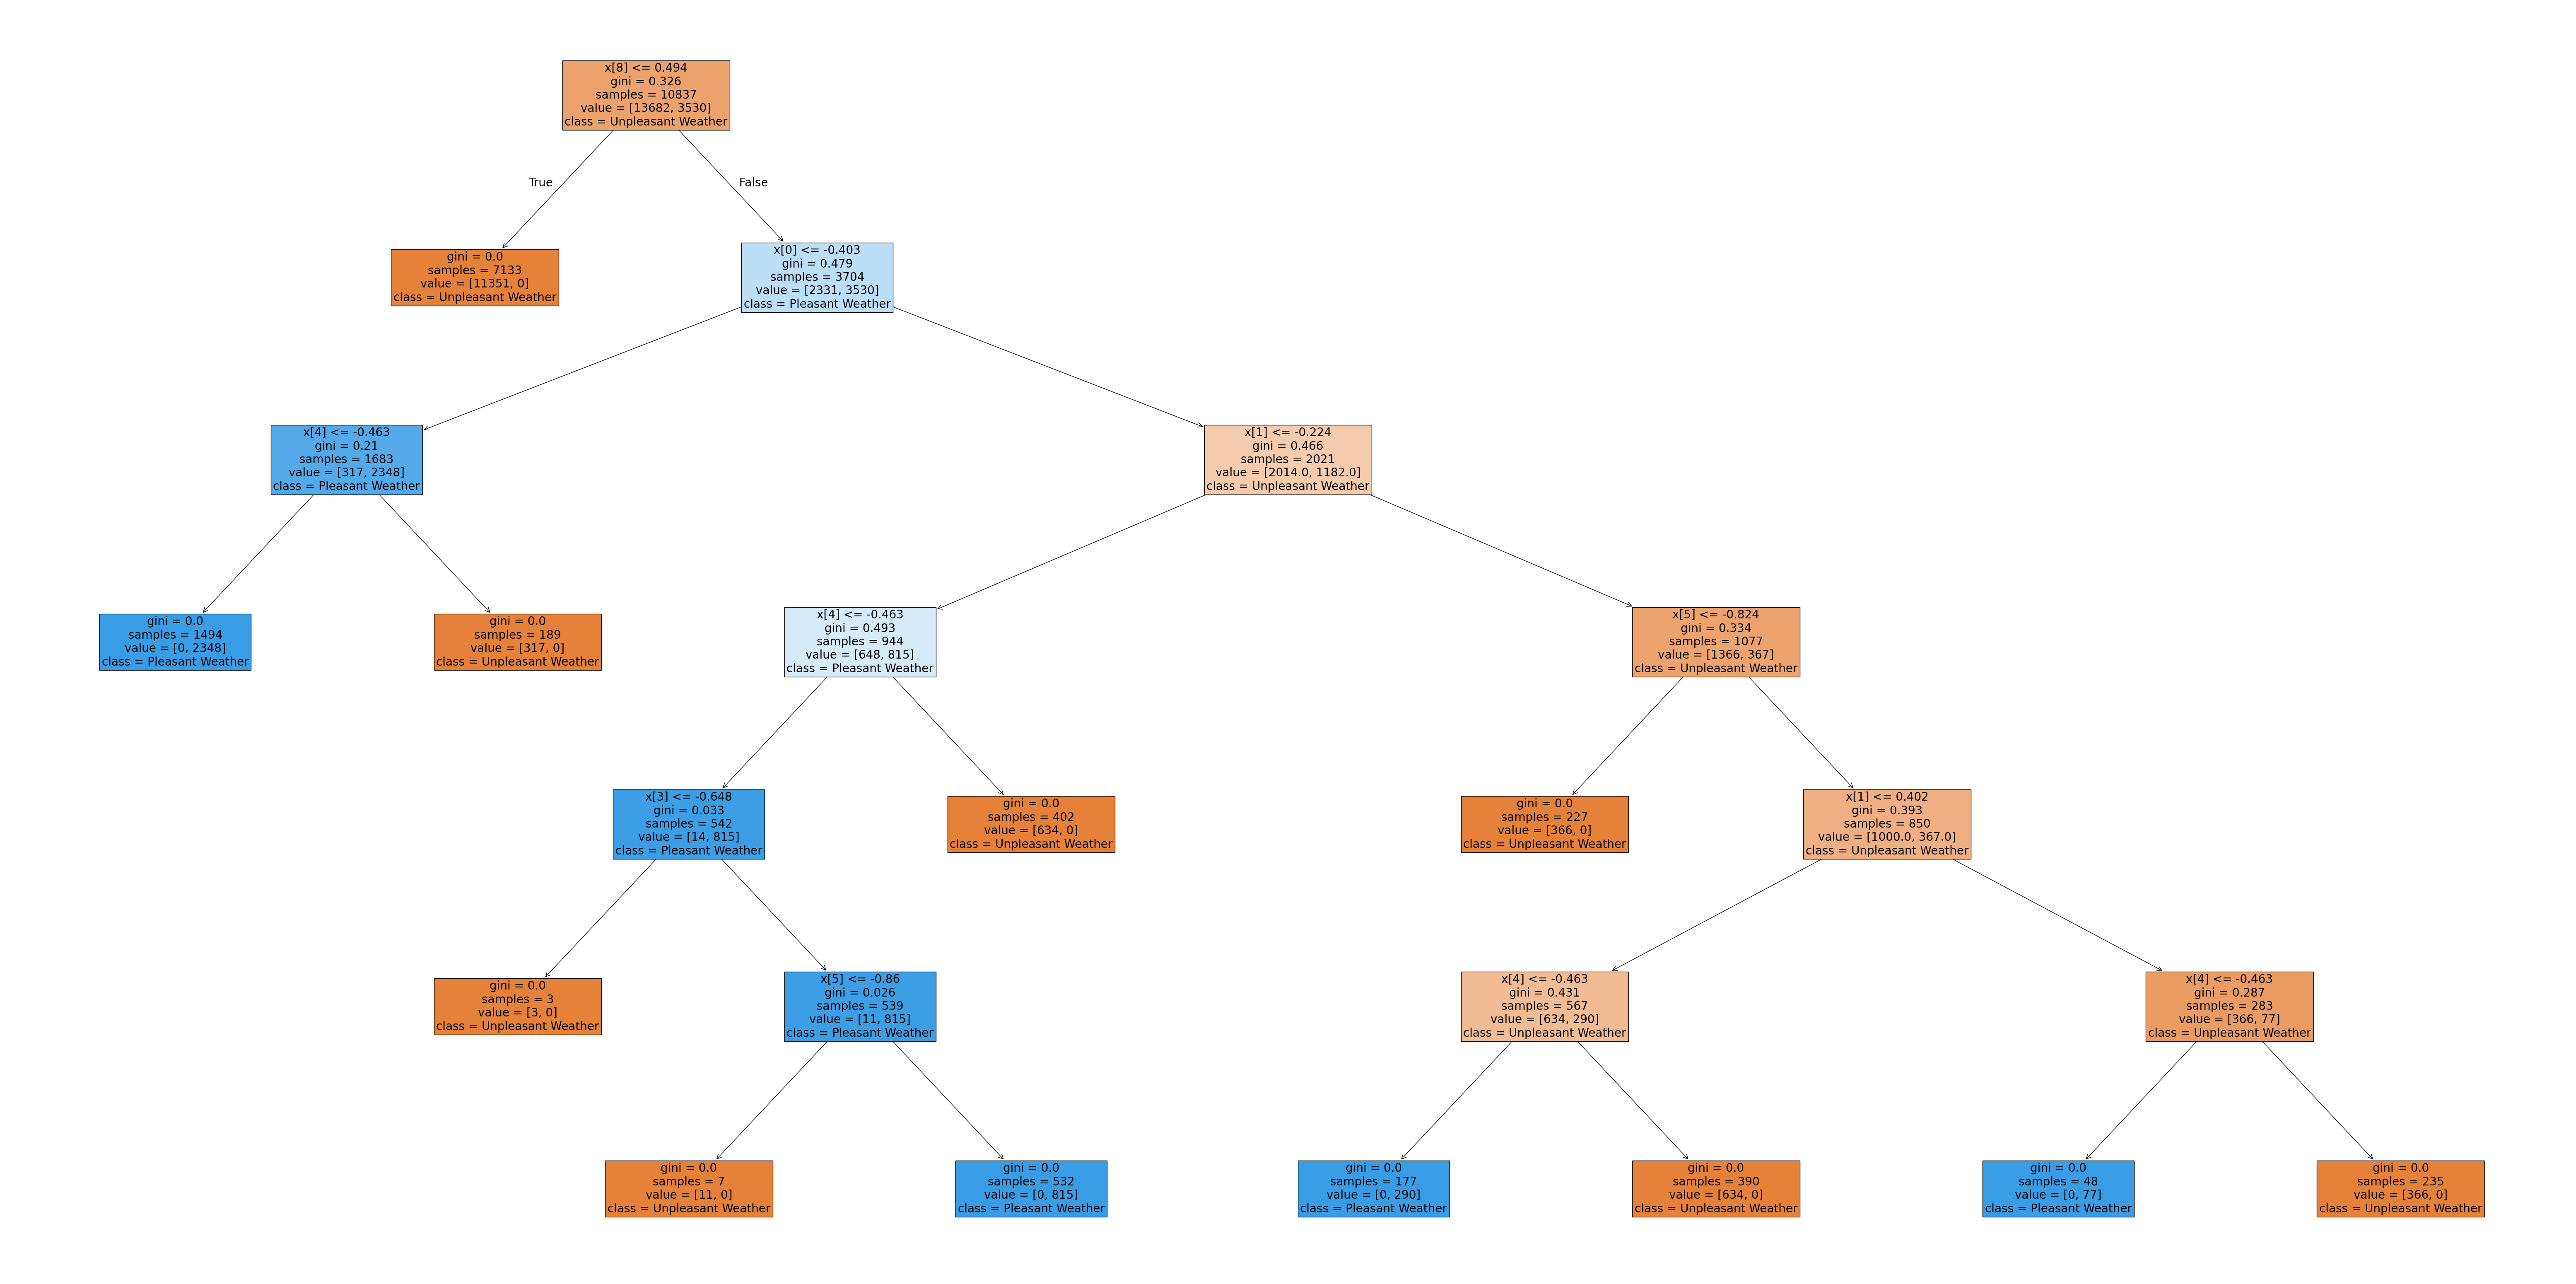

In [50]:
# Define class names for readability
class_names = ['Unpleasant Weather', 'Pleasant Weather']

# Plot the tree
fig = plt.figure(figsize=(80, 40))
plot_tree(clf.estimators_[15], 
          filled=True, 
          fontsize=20,
          feature_names=None,  # You can add your feature names here if you'd like
          class_names=class_names);  # Adds class labels at the leaves

### 06 Feature Importance Analysis

In [52]:
# Retrieve feature importances from the trained model

newarray = clf.feature_importances_
print(clf.feature_importances_.shape) # Should print: (9,)
newarray # This shows the raw importance values

(9,)


array([0.02589165, 0.02854016, 0.0126022 , 0.09899427, 0.31861322,
       0.07640981, 0.12403364, 0.0267683 , 0.28814674])

In [53]:
# Clean feature names from Maastricht columns

Maastricht_features = [feature.replace('MAASTRICHT_', '') for feature in Maastricht_station]
Maastricht_features

['cloud_cover',
 'humidity',
 'pressure',
 'global_radiation',
 'precipitation',
 'sunshine',
 'temp_mean',
 'temp_min',
 'temp_max']

In [54]:
# Create Series for feature importance

important = pd.Series(newarray, index=Maastricht_features).sort_values(ascending=False)
important

precipitation       0.318613
temp_max            0.288147
temp_mean           0.124034
global_radiation    0.098994
sunshine            0.076410
humidity            0.028540
temp_min            0.026768
cloud_cover         0.025892
pressure            0.012602
dtype: float64

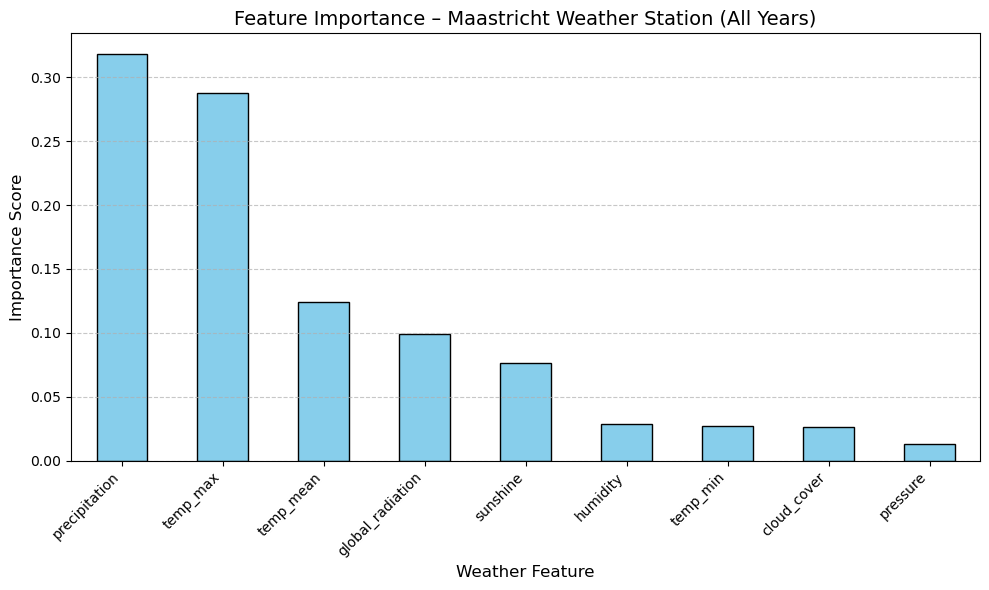

In [55]:
# Plot feature importance

plt.figure(figsize=(10, 6))
important.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Feature Importance – Maastricht Weather Station (All Years)', fontsize=14)
plt.xlabel('Weather Feature', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 07 Insights

The Random Forest model trained on Maastricht’s weather data achieved **100% accuracy** in predicting whether a day was pleasant or not.

- **Precipitation** was the top predictor — days with minimal rain or snow were highly likely to be classified as pleasant.
- **Maximum temperature (temp_max)** was also a major factor, showing that warmer daily highs correlate strongly with pleasant weather.
- **Mean temperature**, **solar radiation**, and **sunshine** played supporting roles in influencing the model's decisions.

Lower-importance features included **humidity**, **minimum temperature**, **cloud cover**, and **air pressure**, which had relatively small effects on the model’s predictions.